# `generate_scm_gamma_26()`

This notebook presents the **generate scm gamma 26** research workflow and key analysis steps.


This scenario produces synthetic panel data with one treated unit and multiple donors. It uses a low-level **Gamma DGP** to simulate realistic outcomes with time-varying exposure and latent rates.


# DGP math


The Data Generating Process (DGP) for the Gamma SCM scenario follows a hierarchical log-linear model for the mean $\mu$, with observations $y$ sampled from a Gamma distribution.


## 1.1 Donor units


For each donor unit $j$ at time $t$:
1. **Exposure** $E_{tj}$:
   $$\log(E_{tj}) = \alpha_j + \gamma_j (t - \bar{t}) + \epsilon_t^{\text{common\_exp}} + \epsilon_{tj}^{\text{donor\_exp}}$$
   where $\epsilon_t^{\text{common\_exp}}$ and $\epsilon_{tj}^{\text{donor\_exp}}$ are AR(1) processes.
2. **Mean** $\mu_{tj}$:
   $$\mu_{tj} = E_{tj} \cdot \exp(\eta_{tj})$$
   $$\eta_{tj} = \beta_j + \delta_j (t - \bar{t}) + \lambda_j S_t + L_t + \sum_{k} \phi_{jk} F_{tk} + \epsilon_{tj}^{\text{donor\_noise}}$$
   where:
   - $S_t$: monthly seasonality signal
   - $L_t$: common factor (macro log index, AR(1))
   - $F_{tk}$: latent factors (AR(1))
   - $\epsilon_{tj}^{\text{donor\_noise}}$: donor-specific AR(1) noise
3. **Outcome** $y_{tj}$:
   $$y_{tj} \sim \text{Gamma}\left(k, \frac{\mu_{tj}}{k}\right)$$
   where $k$ is the `gamma_shape` parameter.


## 1.2 Treated unit


The counterfactual mean $\mu_{t, cf}$ is a weighted combination of donors, potentially with a pre-fit mismatch:
$$\mu_{t, cf} = \left( \sum_j w_j \mu_{tj} \right) \cdot \exp(\epsilon_t^{\text{mismatch}})$$
where $w \sim \text{Dirichlet}(\alpha)$.

Treatment is active only in post periods. For post step $k = 0,1,\dots,n_{post}-1$:
$$r_k = 1 - e^{-(k+1)/2.5}, \qquad \tau_k^{\text{rate}} = (\beta_0 + \beta_1 k)\,r_k$$
where $\beta_0$ is `treatment_effect_rate` and $\beta_1$ is `treatment_effect_slope`.

Equivalently, in calendar time:
$$\tau_t^{\text{rate}} = 0 \text{ in pre/anchor periods, and } \tau_t^{\text{rate}} = \tau_k^{\text{rate}} \text{ in post period } k.$$
$$\mu_{t, treated} = \mu_{t, cf} \cdot (1 + \tau_t^{\text{rate}})$$

The outcomes are:
$$y_{t, cf} \sim \text{Gamma}\left(k, \frac{\mu_{t, cf}}{k}\right)$$
$$y_{t, treated} = y_{t, cf} \cdot (1 + \tau_t^{\text{rate}})$$
So for each $t$, $y_{t, treated}$ remains Gamma-distributed with mean $\mu_{t, treated}$, and $y_{t, treated} - y_{t, cf}$ is exactly the realized treatment effect.


### 2. Oracle Treatment Effects (ATT)


The Average Treatment Effect on the Treated (ATT) is the average impact of the intervention across all post-treatment periods. In this synthetic scenario, we can calculate it in two ways:

1. **Realized ATT**: Based on observed vs. counterfactual outcomes.
$$ \text{ATT}_{realized} = \frac{1}{T_{post}} \sum_{t \in \text{Post}} (Y_t - Y_t^{(0)}) $$
In the data, this is the mean of `tau_realized_true` for the treated unit in post-periods.

2. **Mean ATT**: Based on the underlying population means (the "signal").
$$ \text{ATT}_{mean} = \frac{1}{T_{post}} \sum_{t \in \text{Post}} (\mu_t^{(1)} - \mu_t^{(0)}) $$
In the data, this is the mean of `tau_mean_true` for the treated unit in post-periods.


In [1]:
import numpy as np
import pandas as pd

from causalis.scenarios.synthetic_control import generate_scm_gamma_26

df = generate_scm_gamma_26(
    include_oracles=True,
    return_panel_data=False,
    seed=42,
)

# Treated post-period rows are exactly treated_time == 1
post_treated = df[df["treated_time"] == 1].copy()
atte_true = post_treated["tau_realized_true"].mean()
relative_lift_realized = (post_treated["tau_realized_true"] / post_treated["y_cf"]).mean()

print(f"Ground-truth ATTE is {atte_true:.6f}")

Ground-truth ATTE is 1.919269


In [2]:
df.head()

,unit_id,calendar_time,treated_time,y,y_cf,tau_realized_true,mu_cf,mu_treated,tau_mean_true
0,donor_1,2000-01,0,9.971611,9.971611,0.0,10.059081,10.059081,0.0
1,donor_1,2000-02,0,10.344379,10.344379,0.0,10.097467,10.097467,0.0
2,donor_1,2000-03,0,10.998498,10.998498,0.0,11.354098,11.354098,0.0
3,donor_1,2000-04,0,11.508717,11.508717,0.0,11.277716,11.277716,0.0
4,donor_1,2000-05,0,11.125281,11.125281,0.0,10.098791,10.098791,0.0


In [3]:
from causalis.data_contracts import PanelDataSCM

paneldata = PanelDataSCM(
    df=df,
    y='y',
    unit_col='unit_id',
    time_col='calendar_time',
    treated_time='treated_time'
)

# EDA

In [4]:
paneldata

PanelDataSCM(df=(1763, 4), y='y', unit_col='unit_id', time_col='calendar_time', treated_time='treated_time', time_freq='M', treated_unit='treated', treatment_start=Period('2003-02', 'M'), last_post_period=Period('2003-07', 'M'), n_pre_periods=37, n_post_periods=6, donor_units=['donor_1', 'donor_10', 'donor_11', 'donor_12', 'donor_13', 'donor_14', 'donor_15', 'donor_16', 'donor_17', 'donor_18', 'donor_19', 'donor_2', 'donor_20', 'donor_21', 'donor_22', 'donor_23', 'donor_24', 'donor_25', 'donor_26', 'donor_27', 'donor_28', 'donor_29', 'donor_3', 'donor_30', 'donor_31', 'donor_32', 'donor_33', 'donor_34', 'donor_35', 'donor_36', 'donor_37', 'donor_38', 'donor_39', 'donor_4', 'donor_40', 'donor_5', 'donor_6', 'donor_7', 'donor_8', 'donor_9'])

In [5]:
from causalis.scenarios.synthetic_control.refutation import donors_diagnostics
donors_diagnostics(paneldata)

,donor,pre_mean,pre_std,pre_slope,corr_with_treated_pre,rmse_to_treated_pre,rmse_to_treated_pre_standardized,mean_diff_pre,slope_diff_pre,max_abs_gap_pre,is_never_treated,n_missing_pre,corr_rank,std_rmse_rank,slope_rank,composite_similarity_score,rank_by_similarity,notes
0,donor_20,20.756877,4.235256,0.065672,0.699298,3.050574,1.177242,0.055800,0.001045,7.515230,True,0,6,2,1,0.950000,1,high_std_rmse
1,donor_23,18.859982,3.459160,0.109325,0.792879,2.802849,1.081642,-1.841096,0.044698,6.193337,True,0,1,1,19,0.850000,2,high_std_rmse
2,donor_17,27.374399,5.004251,0.062159,0.694945,7.633294,2.945751,6.673322,-0.002467,15.022205,True,0,7,23,3,0.750000,3,high_std_rmse
3,donor_35,12.890196,2.478484,0.054896,0.774341,7.995072,3.085364,-7.810882,-0.009730,11.244939,True,0,2,25,7,0.741667,4,high_std_rmse
4,donor_27,12.138052,2.561773,0.065732,0.710107,8.784934,3.390178,-8.563025,0.001106,12.226100,True,0,4,29,2,0.733333,5,high_std_rmse
5,donor_39,15.933235,3.493479,0.101601,0.756099,5.287926,2.040654,-4.767843,0.036974,9.398086,True,0,3,16,16,0.733333,6,high_std_rmse
6,donor_2,22.023910,3.752940,0.025593,0.599773,3.299044,1.273128,1.322833,-0.039033,8.913091,True,0,19,4,17,0.691667,7,high_std_rmse
7,donor_34,23.225266,4.258988,0.116799,0.685302,4.012347,1.548398,2.524189,0.052173,8.782578,True,0,8,11,21,0.691667,8,high_std_rmse
8,donor_26,15.531548,2.367240,0.058569,0.584382,5.645636,2.178697,-5.169529,-0.006057,10.132082,True,0,21,18,5,0.658333,9,high_std_rmse
9,donor_9,20.198346,3.894696,0.185173,0.609819,3.134843,1.209762,-0.502731,0.120546,10.776096,True,0,15,3,31,0.616667,10,high_std_rmse


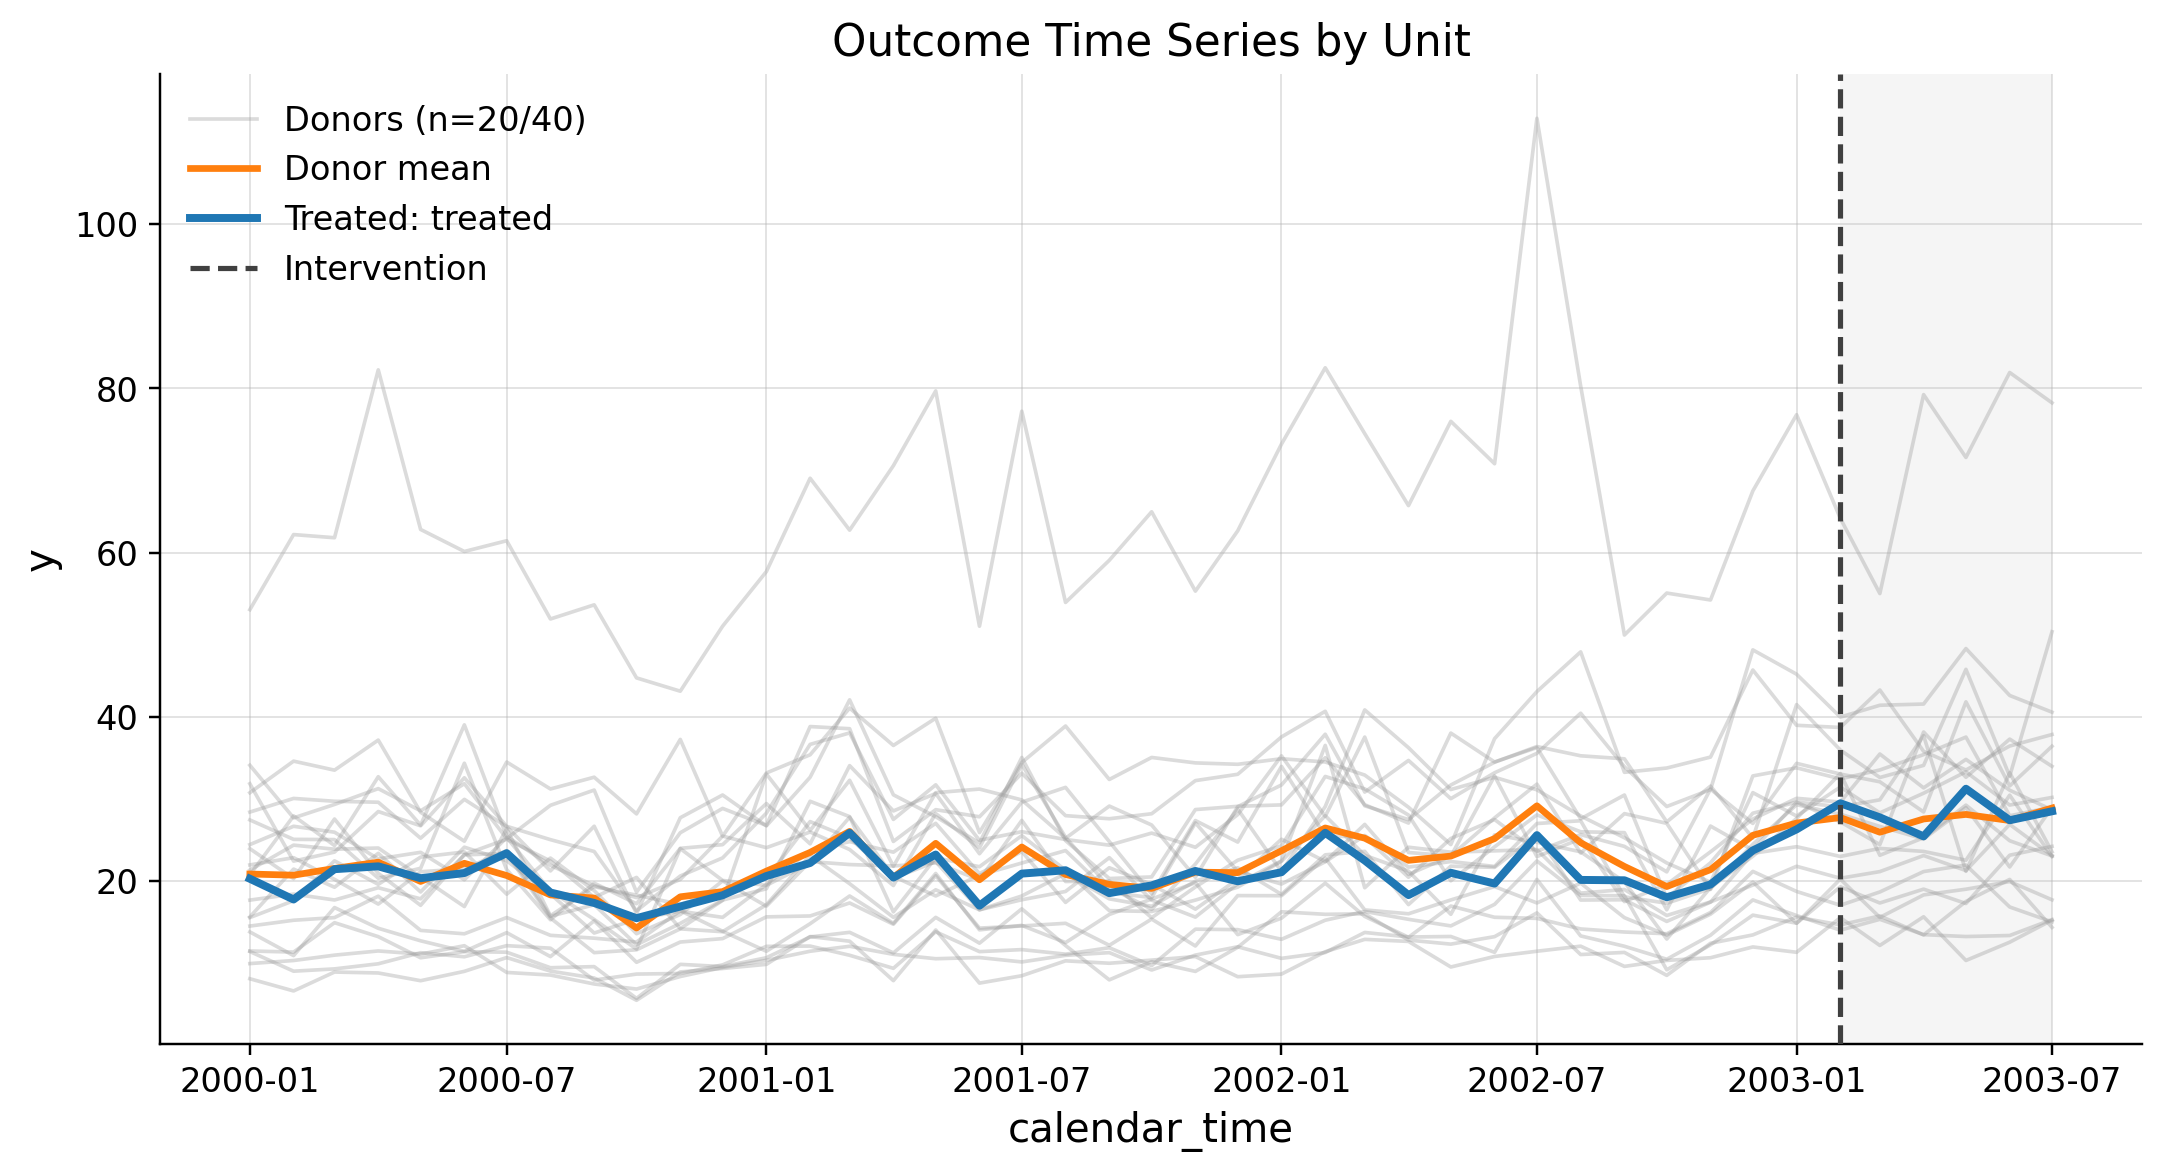

In [6]:
from causalis.scenarios.synthetic_control.refutation import outcome_panel_plot

outcome_panel_plot(paneldata)